# **PRÁCTICA 1**


### 6.4 Utilizar modelo final para obtener predicciones sobre competition

Este codigo se encarga de utilizar el modelo ya entrenado para generar predicciones sobre los datos del conjunto de competicion. Primero, se carga el modelo guardado previamente desde el fichero (`modelo_final.joblib`). A continuación, se leen los datos del conjunto de competicion, sobre los cuales no se conoce la variable objetivo. Antes de realizar las predicciones, se aplica el mismo preprocesamiento utilizado durante el entrenamiento, como la transformacion de valores desconocidos en variables como `education` o `pdays`, y la creacion de la variable derivada `contactado_previamente`.

Finalmente, las predicciones se guardan en `predicciones.csv` con etiquetas explicitas `yes/no` para evitar ambiguedad en la interpretacion.


### Nota breve sobre uso de IA

En este notebook la IA se utilizó unicamente como apoyo de redaccion y de comprobacion de consistencia del flujo de exportacion.

La generacion de `predicciones.csv` proviene del modelo entrenado y de su ejecucion en codigo, validada por los autores.


In [1]:
import numpy as np
import pandas as pd
import joblib

modelo_final = joblib.load('modelo_final.joblib')

df_competition = pd.read_pickle("bank_competition_09.pkl")

# MISMO PREPROCESADO QUE TRAIN
df_competition['education'] = df_competition['education'].replace('unknown', np.nan)
df_competition['pdays'] = df_competition['pdays'].replace(-1, np.nan)

df_competition['contactado_previamente'] = df_competition['pdays'].apply(
    lambda x: 0 if pd.isna(x) else 1
)

predicciones = modelo_final.predict(df_competition)
predicciones_label = pd.Series(predicciones).map({0: 'no', 1: 'yes'})

pd.DataFrame(predicciones_label, columns=['deposit']).to_csv('predicciones.csv', index=False)

print("predicciones.csv generado correctamente")


predicciones.csv generado correctamente


## Apartado 8: **TAREA DE ELECCIÓN ABIERTA**

Como tarea adicional, hemos pensado que sería muy buena idea obtener una probabilidad además de una clase como resultado. De esta forma, el modelo no solo indica la clase predicha, sino también la probabilidad asociada a cada una de las clases, es decir, la probabilidad que tiene un cliente de realizar un depósito o no.

Esto nos parece algo interesante ya que permite conocer no solo la predicción final del modelo, sino también qué tan probable considera el modelo cada una de las opciones, aportando de esta manera un valor añadido.

Por todo ello, el uso de predict_proba mejora la calidad de las predicciones al aportar información adicional que no se obtiene con la predicción simple de clases.

### 8.1 Implementacion de probabilidades en el modelo

Para que la app de Streamlit y el analisis de confianza sean utiles en un contexto real, usamos el mejor modelo (`SVM RBF`) con salida probabilistica (`predict_proba`).

Esto permite distinguir entre predicciones con baja confianza (por ejemplo, 0.51) y alta confianza (por ejemplo, 0.93), incluso cuando ambas pertenezcan a la misma clase final.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, f1_score, precision_score, recall_score

SEED = 100522245

# Dataset original para evaluar probabilidades en un holdout reproducible
df_eval = pd.read_pickle('bank_09.pkl').copy()
df_eval['education'] = df_eval['education'].replace('unknown', np.nan)
df_eval['pdays'] = df_eval['pdays'].replace(-1, np.nan)
df_eval['contactado_previamente'] = df_eval['pdays'].apply(lambda x: 0 if pd.isna(x) else 1)

X = df_eval.drop(columns='deposit')
y = df_eval['deposit'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, stratify=y, random_state=SEED
)

# Usamos la misma pipeline final, pero ajustada solo en train para evaluar en test
modelo_template = joblib.load('modelo_final.joblib')
modelo_eval = clone(modelo_template)
modelo_eval.fit(X_train, y_train)

if not hasattr(modelo_eval, 'predict_proba'):
    raise RuntimeError('El modelo final no expone predict_proba. Revisar la configuracion de SVM.')

y_prob = modelo_eval.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

res_test = X_test.copy()
res_test['real'] = y_test.values
res_test['pred'] = y_pred
res_test['prob_yes'] = y_prob

display(res_test[['real', 'pred', 'prob_yes']].head(10))

casos_si = res_test[res_test['pred'] == 1].sort_values('prob_yes')
if len(casos_si) >= 2:
    ejemplo_baja = casos_si.iloc[0][['real', 'pred', 'prob_yes']]
    ejemplo_alta = casos_si.iloc[-1][['real', 'pred', 'prob_yes']]
    print('Ejemplo SI con baja confianza:', ejemplo_baja.to_dict())
    print('Ejemplo SI con alta confianza:', ejemplo_alta.to_dict())

print('Interpretacion: estas probabilidades permiten priorizar llamadas comerciales, empezando por clientes con mayor prob_yes.')

,real,pred,prob_yes
7683,0,1,0.622402
1953,1,1,0.805242
2798,1,1,0.972007
2230,1,1,0.818481
1054,1,1,0.802439
468,1,1,0.671227
7951,0,0,0.268410
9700,0,0,0.057353
9142,0,0,0.073661
2150,1,1,0.991176


Ejemplo SI con baja confianza: {'real': 0, 'pred': 1, 'prob_yes': 0.5}
Ejemplo SI con alta confianza: {'real': 1, 'pred': 1, 'prob_yes': 0.9999907332369415}
Interpretacion: estas probabilidades permiten priorizar llamadas comerciales, empezando por clientes con mayor prob_yes.


### 8.2 Fiabilidad de las probabilidades: Brier Score y calibracion

Medimos la calidad probabilistica con **Brier score** (cuanto mas bajo, mejor) y mostramos una **curva de calibracion** para ver si el modelo esta bien alineado entre probabilidad predicha y frecuencia real.

Brier score (test): 0.113036


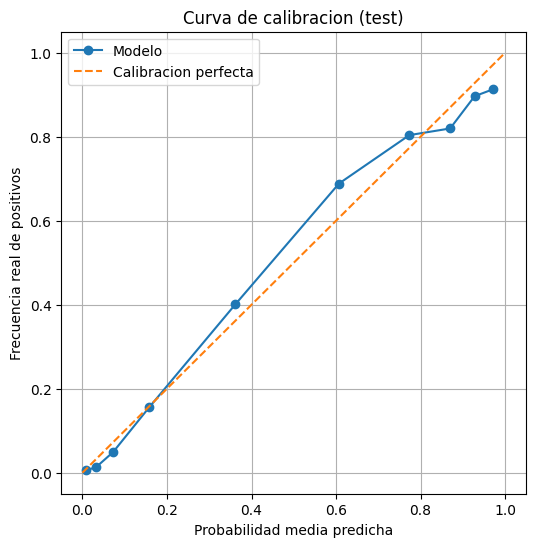

In [3]:
brier = brier_score_loss(y_test, y_prob)
print(f'Brier score (test): {brier:.6f}')

frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(mean_pred, frac_pos, marker='o', label='Modelo')
plt.plot([0, 1], [0, 1], '--', label='Calibracion perfecta')
plt.xlabel('Probabilidad media predicha')
plt.ylabel('Frecuencia real de positivos')
plt.title('Curva de calibracion (test)')
plt.legend()
plt.grid(True)
plt.show()

### 8.3 Analisis de umbral de decision

El umbral 0.5 no es unico. Evaluamos varios umbrales para mostrar como cambian `precision`, `recall` y `F1`.

Esto permite adaptar la estrategia comercial: por ejemplo, subir umbral para contactar menos clientes pero con mayor probabilidad de exito, o bajarlo para captar mas potenciales clientes asumiendo mas falsos positivos.

,threshold,precision,recall,f1,predicted_yes
0,0.30,0.773117,0.932184,0.845232,2098
1,0.35,0.789266,0.921264,0.850172,2031
2,0.40,0.801328,0.901724,0.848567,1958
3,0.45,0.814678,0.886782,0.849202,1894
4,0.50,0.824332,0.868391,0.845788,1833
5,0.55,0.835632,0.835632,0.835632,1740
6,0.60,0.843750,0.806897,0.824912,1664
7,0.65,0.853257,0.775287,0.812406,1581
8,0.70,0.854447,0.728736,0.786600,1484
9,0.75,0.866716,0.676437,0.759845,1358


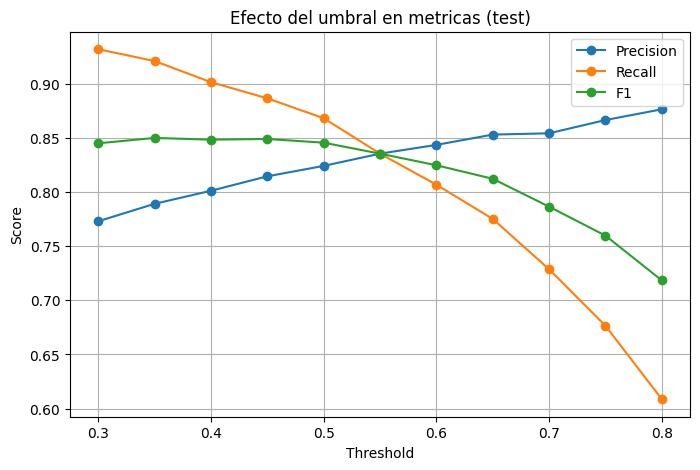

In [4]:
thresholds = np.arange(0.30, 0.81, 0.05)
rows = []

for t in thresholds:
    y_t = (y_prob >= t).astype(int)
    rows.append({
        'threshold': round(float(t), 2),
        'precision': precision_score(y_test, y_t, zero_division=0),
        'recall': recall_score(y_test, y_t, zero_division=0),
        'f1': f1_score(y_test, y_t, zero_division=0),
        'predicted_yes': int(y_t.sum())
    })

df_thresholds = pd.DataFrame(rows)
display(df_thresholds)

plt.figure(figsize=(8, 5))
plt.plot(df_thresholds['threshold'], df_thresholds['precision'], marker='o', label='Precision')
plt.plot(df_thresholds['threshold'], df_thresholds['recall'], marker='o', label='Recall')
plt.plot(df_thresholds['threshold'], df_thresholds['f1'], marker='o', label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Efecto del umbral en metricas (test)')
plt.grid(True)
plt.legend()
plt.show()

### Conclusiones de la tarea abierta

- La salida probabilistica aporta valor practico frente a una prediccion binaria simple.
- La calibracion/Brier permite evaluar si esas probabilidades son fiables.
- El analisis de umbral demuestra que 0.5 no es obligatorio y puede adaptarse al objetivo de negocio del banco.